In [26]:
import pandas as pd
import numpy as np
from collections import Counter

## Data preprocessing

In [27]:
df_spotify = pd.read_csv("../data/spotify_no_null.csv")
df_spotify

,id,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113994,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113995,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113996,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113997,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


### *is_hit* from *popularity*
 

In order to predict if a song would likely to be popular, we add a new column *is_hit* calculated as written here: 

*is_hit = 1 if popularity >= 70*
*is_hit = 1 if popularity >= 70*

*is_hit = 0 otherwise*

In [28]:
df_spotify['is_hit'] = df_spotify['popularity'] >= 70
df_spotify['is_hit']

0          True
1         False
2         False
3          True
4          True
          ...  
113994    False
113995    False
113996    False
113997    False
113998    False
Name: is_hit, Length: 113999, dtype: bool

### Convert *duration_ms* to *duration_s*
This is just for usability, it's easier to read *seconds* instead of *milliseconds*

In [29]:
df_spotify = df_spotify.rename(columns={'duration_ms': 'duration_s'})
df_spotify['duration_s'] = pd.DataFrame(df_spotify['duration_s'] / 1000).astype(float)
df_spotify['duration_s']

0         230
1         149
2         210
3         201
4         198
         ... 
113994    384
113995    385
113996    271
113997    283
113998    241
Name: duration_s, Length: 113999, dtype: int32

### Save dataset for third research question analysis

In [ ]:
df_spotify.to_csv("../data/spotify_mid.csv", index=False)

### *track_genre* preprocessing and engineering
Dataset contains a total of 114 unique genre entries, to simplify usage all subgenres are reunited under their main genre. Specific genres are labeled after the most similar main genre, based on technical song features

In [30]:
genres = df_spotify["track_genre"].unique()
genres

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

In [31]:
Counter(df_spotify["track_genre"])

Counter({'acoustic': 1000,
         'afrobeat': 1000,
         'alt-rock': 1000,
         'alternative': 1000,
         'ambient': 1000,
         'anime': 1000,
         'black-metal': 1000,
         'bluegrass': 1000,
         'blues': 1000,
         'brazil': 1000,
         'breakbeat': 1000,
         'british': 1000,
         'cantopop': 1000,
         'chicago-house': 1000,
         'children': 1000,
         'chill': 1000,
         'classical': 1000,
         'club': 1000,
         'comedy': 1000,
         'country': 1000,
         'dance': 1000,
         'dancehall': 1000,
         'death-metal': 1000,
         'deep-house': 1000,
         'detroit-techno': 1000,
         'disco': 1000,
         'disney': 1000,
         'drum-and-bass': 1000,
         'dub': 1000,
         'dubstep': 1000,
         'edm': 1000,
         'electro': 1000,
         'electronic': 1000,
         'emo': 1000,
         'folk': 1000,
         'forro': 1000,
         'french': 1000,
         'funk': 1000,

In [32]:
def group_genres(genres):
    categories = {
        "rock": ["emo", "garage", "goth", "grunge", "metal", "punk", "rock"],

        "pop": ["pop", "songwriter"],

        "blues": ["blue", "funk", "gospel", "jazz", "soul"],

        "hip-hop": ["hip-hop", "r-n-b"],

        "latin": ["brazil", "forro", "latin", "mpb", "pagode", "reggaeton", "salsa", "samba", "sertanejo", "tango"],

        "classical": ["classical", "opera", "piano"],

        "dance": ["breakbeat", "drum-and-bass", "dance", "disco", "dub", "edm", "electro", "hardcore", "hardstyle", "house", "idm", "techno", "trance", "trip-hop"]
    }

    # Inizializza i gruppi
    grouped = {key: [] for key in categories}
    grouped["other"] = []

    # Matching dei generi
    for g in genres:
        found = False
        for cat, items in categories.items():
            if any(k in g for k in items):
                grouped[cat].append(g)
                found = True
                break
        if not found:
            grouped["other"].append(g)

    return grouped

grouped = group_genres(genres)

for cat, items in grouped.items():
    print(cat, "=>", items)

mapped_genres = []
for genre in df_spotify["track_genre"]:
    for cat, items in grouped.items():
        if genre in items:
            mapped_genres.append(cat)

df_spotify["new_track_genre"] = mapped_genres
Counter(df_spotify["new_track_genre"])

rock => ['alt-rock', 'black-metal', 'death-metal', 'emo', 'garage', 'goth', 'grunge', 'hard-rock', 'heavy-metal', 'j-rock', 'metal', 'metalcore', 'psych-rock', 'punk-rock', 'punk', 'rock-n-roll', 'rock', 'rockabilly']
pop => ['cantopop', 'indie-pop', 'j-pop', 'k-pop', 'mandopop', 'pop-film', 'pop', 'power-pop', 'singer-songwriter', 'songwriter', 'synth-pop']
blues => ['bluegrass', 'blues', 'funk', 'gospel', 'jazz', 'soul']
hip-hop => ['hip-hop', 'r-n-b']
latin => ['brazil', 'forro', 'latin', 'latino', 'mpb', 'pagode', 'reggaeton', 'salsa', 'samba', 'sertanejo', 'tango']
classical => ['classical', 'opera', 'piano']
dance => ['breakbeat', 'chicago-house', 'dance', 'dancehall', 'deep-house', 'detroit-techno', 'disco', 'drum-and-bass', 'dub', 'dubstep', 'edm', 'electro', 'electronic', 'hardcore', 'hardstyle', 'house', 'idm', 'j-dance', 'minimal-techno', 'progressive-house', 'techno', 'trance', 'trip-hop']
other => ['acoustic', 'afrobeat', 'alternative', 'ambient', 'anime', 'british', 'chil

Counter({'other': 40000,
         'dance': 23000,
         'rock': 18000,
         'latin': 11000,
         'pop': 10999,
         'blues': 6000,
         'classical': 3000,
         'hip-hop': 2000})

"Other" genres are now relabeled based on 5-NN distance computed after 3-components PCA analysis

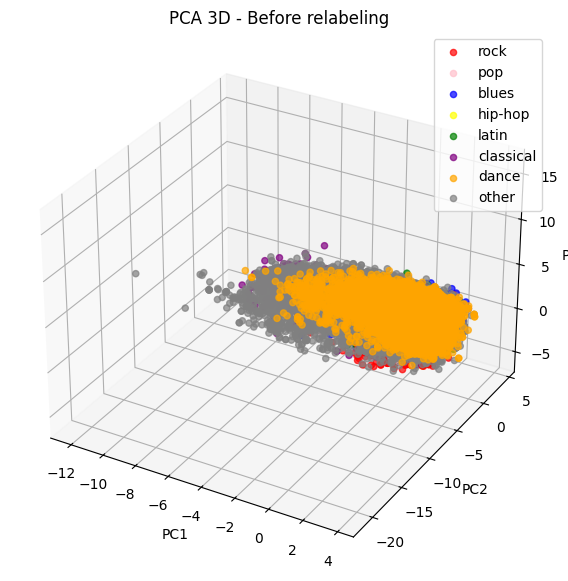

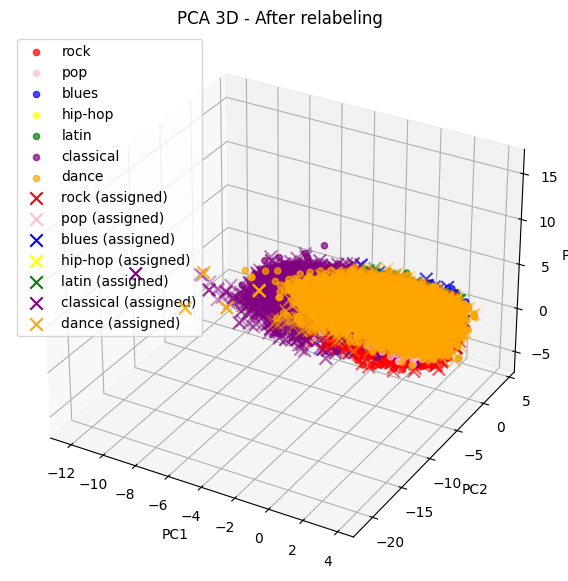

Predicted labels: Counter({'dance': 11299, 'rock': 7633, 'latin': 6212, 'pop': 6087, 'classical': 4950, 'blues': 3437, 'hip-hop': 382})
Final genres: Counter({'dance': 34299, 'rock': 25633, 'latin': 17212, 'pop': 17086, 'blues': 9437, 'classical': 7950, 'hip-hop': 2382})


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

def classify_others_pca_knn(cols, n_components=3, k=5):
    main_categories = ["rock", "pop", "blues", "hip-hop", "latin", "classical", "dance"]

    df_main = df_spotify[df_spotify["new_track_genre"].isin(main_categories)].copy()
    df_others = df_spotify[df_spotify["new_track_genre"] == "other"].copy()

    # scaling
    scaler = StandardScaler()
    X_main_scaled = scaler.fit_transform(df_main[cols])
    X_others_scaled = scaler.transform(df_others[cols])

    # PCA
    pca = PCA(n_components=n_components)
    X_main_pca = pca.fit_transform(X_main_scaled)
    X_others_pca = pca.transform(X_others_scaled)

    # plot clusters before relabeling
    plot_pca_3d(X_main=X_main_pca, y_main=df_main["new_track_genre"].values,
                X_others=X_others_pca, main_categories=main_categories,
                title="PCA 3D - Before relabeling")
    
    # KNN relabeling
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_main_pca, df_main["new_track_genre"])

    predicted = knn.predict(X_others_pca)
    df_spotify.loc[df_others.index, "new_track_genre"] = predicted

    # replot clusters after relabeling
    plot_pca_3d(X_main=X_main_pca, y_main=df_main["new_track_genre"].values,
                X_others=X_others_pca, main_categories=main_categories,
                assigned_labels=predicted, title="PCA 3D - After relabeling")
    
    print(f"Predicted labels: {Counter(predicted)}")
    print(f"Final genres: {Counter(df_spotify["new_track_genre"])}")

def plot_pca_3d(X_main, y_main, X_others, main_categories, title, assigned_labels=None):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    colors = {
        "rock": "red",
        "pop": "pink",
        "blues": "blue",
        "hip-hop": "yellow",
        "latin": "green",
        "classical": "purple",
        "dance": "orange"
    }

    for cat in main_categories:
        idx = np.where(y_main == cat)[0]
        if len(idx) > 0:
            ax.scatter(
                X_main[idx, 0], X_main[idx, 1], X_main[idx, 2],
                c=colors[cat], label=cat, alpha=0.7, marker="o"
            )

    if assigned_labels is None:
        # first plot: original "Other"
        ax.scatter(
                X_others[:, 0], X_others[:, 1], X_others[:, 2],
                c="grey", label="other", alpha=0.7, marker="o"
            )
    else:
        # second plot: reassigned labels
        for cat in main_categories:
            idx = np.where(assigned_labels == cat)[0]
            if len(idx) > 0:
                ax.scatter(
                        X_others[idx, 0], X_others[idx, 1], X_others[idx, 2],
                        c=colors[cat], label=f"{cat} (assigned)", marker="x", s=80
                    )

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.legend()
    plt.show()
    
technical_cols = ["duration_s", "danceability", "energy", "key", "loudness", "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "time_signature"]
classify_others_pca_knn(technical_cols)

## Save preprocessed data

In [34]:
df_spotify.to_csv("../data/spotify_final.csv", index=False)